In [2]:
import pandas as pd

## **1) 결측치 처리**

- 결측치는 데이터 분석에서 누락된 값을 의미함.
- 이를 처리하지 않으면 분석 결과의 왜곡이 발생할 수 있음.
- 예) 평균이나 분산 같은 통계량을 계산할 때 결측치가 포함되면 정확한 값이 나오지 않음

1. 분석 왜곡: 결측치가 있으면 통계적 분석 결과가 왜곡됨.
2. 모델 학습 문제: 머신러닝 알고리즘이 결측치를 처리하지 못하면 모델 성능이 떨어짐.
3. 비즈니스 의사결정 오류: 잘못된 데이터 기반으로 의사결정을 내리면 큰 손실을 초래할 수 있음.

In [3]:
df = pd.read_csv('01_Contract_Data.csv')
df

,Index,Member_ID,Sales_Type,Contract_Type,Channel,Datetime,Term,Payment_Type,Product_Type,Amount_Month,Customer_Type,Age,Address1,Address2,State,Overdue_count,Overdue_Type,Gender,Credit_Rank,Bank
0,1,66758234,렌탈,일반계약,영업방판,2019-05-06,60,CMS,DES-1,96900,개인,42.0,경기도,경기도,계약확정,0,없음,여자,9.0,새마을금고
1,2,66755948,렌탈,교체계약,영업방판,2020-02-20,60,카드이체,DES-1,102900,개인,39.0,경기도,경기도,계약확정,0,없음,남자,2.0,현대카드
2,3,66756657,렌탈,일반계약,홈쇼핑/방송,2019-02-28,60,CMS,DES-1,96900,개인,48.0,경기도,경기도,계약확정,0,없음,여자,8.0,우리은행
3,4,66423450,멤버십,멤버십3유형,재계약,2019-05-13,12,CMS,DES-1,66900,개인,39.0,경기도,경기도,계약확정,0,없음,남자,5.0,농협회원조합
4,5,66423204,멤버십,멤버십3유형,재계약,2019-05-10,12,CMS,DES-1,66900,개인,60.0,경기도,경기도,기간만료,12,있음,남자,8.0,농협회원조합
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51296,51298,66579515,렌탈,프로모션계약,대형마트A,2019-03-01,60,CMS,DES-3A,96900,개인,47.0,경기도,경기도,계약확정,0,없음,남자,NaN,기업은행
51297,51299,66799558,렌탈,일반계약,대형마트A,2019-04-01,60,CMS,DES-1,96900,개인,42.0,경기도,경기도,계약확정,0,없음,여자,8.0,새마을금고
51298,51300,66799197,렌탈,프로모션계약,영업방판,2019-04-01,39,카드이체,ERA,120900,개인,65.0,서울특별시,서울특별시,계약확정,0,없음,여자,1.0,롯데카드
51299,51301,66792778,렌탈,일반계약,홈쇼핑/방송,2020-02-06,60,카드이체,DES-1,96900,개인,54.0,서울특별시,서울특별시,계약확정,0,없음,여자,2.0,롯데카드


#### **렌탈 서비스나 멤버십 서비스에 가입하여 매월 일정 금액을 지불하며, 각 계약은 60개월 또는 12개월로 기간이 설정되어 있음**
- Index: 데이터의 고유 인덱스.
- Member_ID: 고객의 고유 식별자.
- Sales_Type: 판매 유형 (예: 렌탈, 멤버십 등).
- Contract_Type: 계약 유형 (예: 일반계약, 교체계약, 멤버십 등).
- Channel: 판매 채널 (예: 영업방판, 홈쇼핑/방송 등).
- Datetime: 계약 시작 날짜.
- Term: 계약 기간 (개월 단위).
- Payment_Type: 결제 방식 (예: CMS, 카드이체 등).
- Product_Type: 제품 유형 (예: DES-1 등).
- Amount_Month: 월별 결제 금액.
- Customer_Type: 고객 유형 (예: 개인).
- Age: 고객 나이.
- Address1: 고객 주소의 지역(예: 경기도).
- Address2: 계약 상태가 확정되었는지 혹은 만료되었는지 표시.
- State: 계약 상태 (예: 계약확정, 기간만료 등).
- Overdue_count: 연체 횟수.
- Overdue_Type: 연체 여부 및 연체 유형.
- Gender: 고객 성별.
- Credit_Rank: 신용 등급.
- Bank: 결제 은행.

#### **1. isnull() 또는 isna()** : 결측치를 확인

In [4]:
# 데이터 구조 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51301 entries, 0 to 51300
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          51301 non-null  int64  
 1   Member_ID      51301 non-null  int64  
 2   Sales_Type     51301 non-null  object 
 3   Contract_Type  51301 non-null  object 
 4   Channel        51301 non-null  object 
 5   Datetime       51301 non-null  object 
 6   Term           51301 non-null  int64  
 7   Payment_Type   51301 non-null  object 
 8   Product_Type   51301 non-null  object 
 9   Amount_Month   51301 non-null  int64  
 10  Customer_Type  51299 non-null  object 
 11  Age            44329 non-null  float64
 12  Address1       51299 non-null  object 
 13  Address2       51299 non-null  object 
 14  State          51301 non-null  object 
 15  Overdue_count  51301 non-null  int64  
 16  Overdue_Type   51301 non-null  object 
 17  Gender         51301 non-null  object 
 18  Credit

In [5]:
# isnull() : 결측값을 찾아서 True로 출력
df.isnull()

,Index,Member_ID,Sales_Type,Contract_Type,Channel,Datetime,Term,Payment_Type,Product_Type,Amount_Month,Customer_Type,Age,Address1,Address2,State,Overdue_count,Overdue_Type,Gender,Credit_Rank,Bank
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51296,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
51297,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51298,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
51299,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
# isnull()과 sum()을 중첩해서 항목별 결측치의 합을 확인 확인

## 각 컬럼별 null 값의 갯수 
# df.isnull().sum()

## null 값의 전체 갯수
df.isnull().sum().sum()

18518

In [9]:
# 특정 항목의 결측치 확인하기, 데이터 프레임으로 보기
조건1 = df['Age'].isnull()
df.loc[조건1]

,Index,Member_ID,Sales_Type,Contract_Type,Channel,Datetime,Term,Payment_Type,Product_Type,Amount_Month,Customer_Type,Age,Address1,Address2,State,Overdue_count,Overdue_Type,Gender,Credit_Rank,Bank
22,23,66758074,렌탈,일반계약,영업방판,2020-07-23,60,CMS,DES-1,96900,개인,NaN,충청도,충청도,계약확정,0,없음,여자,1.0,농협중앙회
23,24,66758074,렌탈,일반계약,영업방판,2019-01-01,60,CMS,DES-2,87900,개인,NaN,충청도,충청도,계약확정,0,없음,여자,1.0,농협중앙회
30,31,25702131,멤버십,멤버십3유형,재계약,2019-04-28,12,CMS,DES-1,66900,사업자,NaN,경기도,경기도,계약확정,0,없음,여자,NaN,기업은행
37,38,25851817,멤버십,멤버십3유형,재계약,2020-01-23,12,CMS,DES-1,96600,사업자,NaN,서울특별시,서울특별시,해약확정,0,없음,여자,NaN,국민은행
55,56,25856039,렌탈,교체계약,영업방판,2019-05-01,60,CMS,DES-1,96900,사업자,NaN,경상도,부산광역시,계약확정,0,없음,여자,NaN,농협중앙회
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51281,51283,66799099,멤버십,멤버십2유형,전문매장H,2019-07-18,36,무통장,DES-1,56979,개인,NaN,전라도,광주광역시,계약확정,0,없음,여자,NaN,NaN
51284,51286,66799094,멤버십,멤버십2유형,전문매장H,2019-02-24,36,무통장,DES-1,54603,개인,NaN,서울특별시,서울특별시,계약확정,0,없음,여자,NaN,NaN
51290,51292,66798812,멤버십,멤버십2유형,전문매장H,2020-01-28,36,무통장,DES-1,54603,개인,NaN,경기도,경기도,계약확정,0,없음,여자,NaN,NaN
51291,51293,25731743,렌탈,일반계약,영업방판,2020-02-12,60,CMS,DES-3A,102900,사업자,NaN,경기도,경기도,계약확정,10,있음,여자,NaN,농협중앙회


In [11]:
# 특정 항목의 결측치 확인하기
df['Age'].isnull().sum()

6972

#### **2. 결측치가 적을 때: 행 삭제**
- dropna() : 결측 값이 있는 전체 행을 삭제

In [12]:
# dropna() : 데이터 프레임 전체에결측치가 있는 행을 찾아서 제거
df_cleaned = df.dropna()

In [14]:
## null 객수 확인하기
# df_cleaned.isnull().sum()
df_cleaned.isnull().sum().sum()

0

In [15]:
# 특정 항목의 결측치를 찾아서 제거하기
df['Age'].isnull().sum()

6972

In [16]:
# Age 열의 결측치를 제거하기
df_cleaned2 = df['Age'].dropna()

# 결측치 확인하기
# df_cleaned2.isnull().sum()

0

#### **3. 결측치가 많을 때: 값 체우기**
- 대표값으로 대체 : 평균, 중앙값, 최빈값
- fillna() : 결측치에 특정 값으로 체워줌

In [36]:
# 결측치 개수 확인하기
df['Credit_Rank'].isnull().sum()

8781

In [37]:
# 통계값 보기
df['Credit_Rank'].describe()

count    42520.000000
mean         3.428810
std          2.213453
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         10.000000
Name: Credit_Rank, dtype: float64

#### **3.1 평균 값으로 대체 : 이상치가 없거나, 이상치가 적을 경우**
- 평균값으로 대체하면 데이터의 분포가 유지되면서 결측치가 처리됨.
- 데이터의 변동성이 크지 않을 때는 평균값으로 대체하는 것이 적합함.

#### **변동성 판단 기준**

**1. 변동계수 (CV)**

- CV = (표준편차 / 평균) × 100으로 계산하며, **CV ≥ 30%**이면 변동성이 큰 것으로 판단.
- 기준:
    - CV < 10%: 변동성 매우 낮음
    - 10% ≤ CV < 20%: 변동성 낮음
    - 20% ≤ CV < 30%: 중간 변동성
    - CV ≥ 30%: 변동성 큼

**2. 범위 (Range)**
- 데이터의 최대값 - 최소값으로 계산하며, 범위가 평균의 2배 이상이면 변동성이 큰 것으로 간주함.
- 예: 평균이 50일 때, 범위가 100 이상이면 데이터가 넓게 퍼져 있어 변동성이 큰 것으로 봄.

**3. 표준편차와 평균의 비율**
- 표준편차가 평균의 50% 이상일 경우 변동성이 큰 것으로 판단함.

- **기준:**
    - 표준편차 < 30%: 변동성 낮음
    - 30% ≤ 표준편차 < 50%: 중간 변동성
    - 표준편차 ≥ 50%: 변동성 큼

**요약**
- 변동계수(CV) ≥ 30%: 변동성 큼.
- 범위가 평균의 2배 이상: 변동성 큼.
- 표준편차가 평균의 50% 이상: 변동성 큼.

In [19]:
# 평균 값으로 체우고 새로운 항목으로 지정하기
df['Credit_Rank(mean)'] = df['Credit_Rank'].fillna(df['Credit_Rank'].mean())
df.head(3)

,Index,Member_ID,Sales_Type,Contract_Type,Channel,Datetime,Term,Payment_Type,Product_Type,Amount_Month,...,Age,Address1,Address2,State,Overdue_count,Overdue_Type,Gender,Credit_Rank,Bank,Credit_Rank(mean)
0,1,66758234,렌탈,일반계약,영업방판,2019-05-06,60,CMS,DES-1,96900,...,42.0,경기도,경기도,계약확정,0,없음,여자,9.0,새마을금고,9.00000
1,2,66755948,렌탈,교체계약,영업방판,2020-02-20,60,카드이체,DES-1,102900,...,39.0,경기도,경기도,계약확정,0,없음,남자,2.0,현대카드,2.00000
2,3,66756657,렌탈,일반계약,홈쇼핑/방송,2019-02-28,60,CMS,DES-1,96900,...,48.0,경기도,경기도,계약확정,0,없음,여자,8.0,우리은행,8.00000
3,4,66423450,멤버십,멤버십3유형,재계약,2019-05-13,12,CMS,DES-1,66900,...,39.0,경기도,경기도,계약확정,0,없음,남자,5.0,농협회원조합,5.00000
4,5,66423204,멤버십,멤버십3유형,재계약,2019-05-10,12,CMS,DES-1,66900,...,60.0,경기도,경기도,기간만료,12,있음,남자,8.0,농협회원조합,8.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51296,51298,66579515,렌탈,프로모션계약,대형마트A,2019-03-01,60,CMS,DES-3A,96900,...,47.0,경기도,경기도,계약확정,0,없음,남자,NaN,기업은행,3.42881
51297,51299,66799558,렌탈,일반계약,대형마트A,2019-04-01,60,CMS,DES-1,96900,...,42.0,경기도,경기도,계약확정,0,없음,여자,8.0,새마을금고,8.00000
51298,51300,66799197,렌탈,프로모션계약,영업방판,2019-04-01,39,카드이체,ERA,120900,...,65.0,서울특별시,서울특별시,계약확정,0,없음,여자,1.0,롯데카드,1.00000
51299,51301,66792778,렌탈,일반계약,홈쇼핑/방송,2020-02-06,60,카드이체,DES-1,96900,...,54.0,서울특별시,서울특별시,계약확정,0,없음,여자,2.0,롯데카드,2.00000


In [20]:
df.isnull().sum()

Index                   0
Member_ID               0
Sales_Type              0
Contract_Type           0
Channel                 0
Datetime                0
Term                    0
Payment_Type            0
Product_Type            0
Amount_Month            0
Customer_Type           2
Age                  6972
Address1                2
Address2                2
State                   0
Overdue_count           0
Overdue_Type            0
Gender                  0
Credit_Rank          8781
Bank                 2759
Credit_Rank(mean)       0
dtype: int64

In [22]:
# 기존 결측치가 있는 열 삭제하기
df2 = df.drop(columns='Credit_Rank')
df2.head(3)

,Index,Member_ID,Sales_Type,Contract_Type,Channel,Datetime,Term,Payment_Type,Product_Type,Amount_Month,Customer_Type,Age,Address1,Address2,State,Overdue_count,Overdue_Type,Gender,Bank,Credit_Rank(mean)
0,1,66758234,렌탈,일반계약,영업방판,2019-05-06,60,CMS,DES-1,96900,개인,42.0,경기도,경기도,계약확정,0,없음,여자,새마을금고,9.0
1,2,66755948,렌탈,교체계약,영업방판,2020-02-20,60,카드이체,DES-1,102900,개인,39.0,경기도,경기도,계약확정,0,없음,남자,현대카드,2.0
2,3,66756657,렌탈,일반계약,홈쇼핑/방송,2019-02-28,60,CMS,DES-1,96900,개인,48.0,경기도,경기도,계약확정,0,없음,여자,우리은행,8.0


#### **3.2 중앙 값으로 대체 : 이상치가 있는 경우**
- 중앙값은 이상치의 영향을 받지 않기 때문에 데이터가 왜곡되지 않음.
- 데이터에 극단적인 값(이상치)이 많을 때 중앙값이 적합함.

**1) 범위 (Range) 기준**
- 최대값 - 최소값으로 계산하며, 범위가 지나치게 클 경우 이상치가 존재할 가능성이 있음.
- 범위가 평균의 2배 이상일 때, 극단값이 포함되었을 가능성이 높음.
- 예: 평균이 50일 때, 범위가 100 이상이면 이상치를 의심할 수 있음.

**2) 표준편차 기준**
- 평균 ± 3 * 표준편차를 벗어나는 값은 이상치로 판단 가능함.

**기준:**
- 값이 평균 - 3 * 표준편차 이하이거나 평균 + 3 * 표준편차 이상일 때, 이상치로 간주함.
- 예: 평균이 20이고 표준편차가 5일 때, -15 이하 또는 35 이상이면 이상치 가능성이 높음.

**3) 시각적 확인 (박스플롯)**
- 박스플롯(Box Plot)은 이상치를 시각적으로 확인하는 데 유용함.
- 박스플롯에서 수염(whisker)을 벗어난 점들은 이상치로 표시됨.

**요약**
- 범위가 평균의 2배 이상: 이상치 포함 가능성 높음.
- 평균 ± 3 * 표준편차 범위를 벗어나면 이상치.
- 박스플롯에서 수염을 벗어난 점은 이상치.

In [51]:
# 중앙값으로 대체
df['Credit_Rank(median)'] = df['Credit_Rank'].fillna(df['Credit_Rank'].median())
df.isnull().sum()

Index                     0
Member_ID                 0
Sales_Type                0
Contract_Type             0
Channel                   0
Datetime                  0
Term                      0
Payment_Type              0
Product_Type              0
Amount_Month              0
Customer_Type             2
Age                    6972
Address1                  2
Address2                  2
State                     0
Overdue_count             0
Overdue_Type              0
Gender                    0
Credit_Rank            8781
Bank                   2759
Credit_Rank(mean)         0
Credit_Rank(median)       0
dtype: int64

In [57]:
df3 = df.drop(columns=['Credit_Rank', 'Credit_Rank(mean)'])
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51301 entries, 0 to 51300
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Index                51301 non-null  int64  
 1   Member_ID            51301 non-null  int64  
 2   Sales_Type           51301 non-null  object 
 3   Contract_Type        51301 non-null  object 
 4   Channel              51301 non-null  object 
 5   Datetime             51301 non-null  object 
 6   Term                 51301 non-null  int64  
 7   Payment_Type         51301 non-null  object 
 8   Product_Type         51301 non-null  object 
 9   Amount_Month         51301 non-null  int64  
 10  Customer_Type        51299 non-null  object 
 11  Age                  44329 non-null  float64
 12  Address1             51299 non-null  object 
 13  Address2             51299 non-null  object 
 14  State                51301 non-null  object 
 15  Overdue_count        51301 non-null 

#### **3.3 앞이나 뒤의 값으로 대체 : 시계열 데이터**
- 시계열 데이터나 연속성이 중요한 데이터의 경우, 앞이나 뒤의 값으로 결측치를 채우는 방법을 사용
- 앞의 값으로 결측치 채우기 (ffill), 뒤의 값으로 결측치 채우기 (bfill)

#### **데이터 설명**
- 거래일자: 2023년 1월 1일부터 영업일 기준 15일간의 날짜.
- 종목명: '삼성전자'
- 시가: 매일 주식이 거래를 시작할 때의 가격 
- 종가: 매일 주식이 거래를 마감할 때의 가격 
- 고가: 하루 동안 주식이 거래된 최고가 
- 저가: 하루 동안 주식이 거래된 최저가
- 거래량: 해당일의 주식 거래량
- 거래금액: 해당일의 주식 거래 금액 

In [23]:
df = pd.read_csv('./04_Stock_data02.csv')
df

,거래일자,종목명,시가,종가,고가,저가,거래량,거래금액
0,2023-01-02,삼성전자,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-03,삼성전자,60000.0,60500.0,61000.0,59500.0,5000.0,30000000.0
2,2023-01-04,삼성전자,60500.0,61000.0,61500.0,60000.0,7000.0,45000000.0
3,2023-01-05,삼성전자,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-01-06,삼성전자,61000.0,61500.0,62000.0,60500.0,8000.0,50000000.0
5,2023-01-09,삼성전자,61500.0,62000.0,62500.0,61000.0,9000.0,60000000.0
6,2023-01-10,삼성전자,NaN,NaN,NaN,NaN,NaN,NaN
7,2023-01-11,삼성전자,62000.0,62500.0,63000.0,61500.0,10000.0,80000000.0
8,2023-01-12,삼성전자,NaN,NaN,NaN,NaN,NaN,NaN
9,2023-01-13,삼성전자,62500.0,63000.0,63500.0,62000.0,7000.0,65000000.0


In [24]:
# 앞의 값으로 결측치 채우기 (ffill)
df_ffill = df.fillna(method='ffill')
df_ffill

,거래일자,종목명,시가,종가,고가,저가,거래량,거래금액
0,2023-01-02,삼성전자,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-03,삼성전자,60000.0,60500.0,61000.0,59500.0,5000.0,30000000.0
2,2023-01-04,삼성전자,60500.0,61000.0,61500.0,60000.0,7000.0,45000000.0
3,2023-01-05,삼성전자,60500.0,61000.0,61500.0,60000.0,7000.0,45000000.0
4,2023-01-06,삼성전자,61000.0,61500.0,62000.0,60500.0,8000.0,50000000.0
5,2023-01-09,삼성전자,61500.0,62000.0,62500.0,61000.0,9000.0,60000000.0
6,2023-01-10,삼성전자,61500.0,62000.0,62500.0,61000.0,9000.0,60000000.0
7,2023-01-11,삼성전자,62000.0,62500.0,63000.0,61500.0,10000.0,80000000.0
8,2023-01-12,삼성전자,62000.0,62500.0,63000.0,61500.0,10000.0,80000000.0
9,2023-01-13,삼성전자,62500.0,63000.0,63500.0,62000.0,7000.0,65000000.0


In [73]:
# 뒤의 값으로 결측치 채우기 (bfill)
df_bfill = df.fillna(method='bfill')
df_bfill

,거래일자,종목명,시가,종가,고가,저가,거래량,거래금액
0,2023-01-02,삼성전자,60000.0,60500.0,61000.0,59500.0,5000.0,30000000.0
1,2023-01-03,삼성전자,60000.0,60500.0,61000.0,59500.0,5000.0,30000000.0
2,2023-01-04,삼성전자,60500.0,61000.0,61500.0,60000.0,7000.0,45000000.0
3,2023-01-05,삼성전자,61000.0,61500.0,62000.0,60500.0,8000.0,50000000.0
4,2023-01-06,삼성전자,61000.0,61500.0,62000.0,60500.0,8000.0,50000000.0
5,2023-01-09,삼성전자,61500.0,62000.0,62500.0,61000.0,9000.0,60000000.0
6,2023-01-10,삼성전자,62000.0,62500.0,63000.0,61500.0,10000.0,80000000.0
7,2023-01-11,삼성전자,62000.0,62500.0,63000.0,61500.0,10000.0,80000000.0
8,2023-01-12,삼성전자,62500.0,63000.0,63500.0,62000.0,7000.0,65000000.0
9,2023-01-13,삼성전자,62500.0,63000.0,63500.0,62000.0,7000.0,65000000.0


## **2) 이상치 처리**

**첫번째 : 일반적인 패턴에서 벗어난 극단적인 값임. 이상치가 발생하는 이유는 여러 가지가 있음.**</br>
**1. 데이터 입력 오류 :** 오타나 잘못된 입력으로 인해 발생함.</br>
    - 예시: 나이를 입력할 때 35를 입력해야 하는데 실수로 350을 입력한 경우 발생함</br>
**2. 측정 오류 :** 데이터를 측정하는 기기나 도구의 문제로 인해 발생함.</br>
    - 예시: 온도계나 혈압 측정기 등이 고장 나면 잘못된 측정값을 기록함.</br>
**3. 데이터 처리 오류 :** 데이터 처리 과정에서 잘못된 계산이나 잘못된 전처리가 원인이 됨.</br>
    - 예시: 데이터 변환 중 단위를 잘못 적용하거나 누락된 데이터를 잘못 처리하는 경우 발생함.</br>

#### **두번째 : 왜 이상치를 처리해야 하나?**
- 분석 결과 왜곡: 이상치가 있으면 평균이나 분산 같은 통계량이 왜곡될 수 있음.
- 모델 성능 저하: 머신러닝 모델은 이상치에 민감할 수 있어, 모델의 예측 성능이 떨어질 수 있음.
- 해석의 어려움: 이상치를 포함한 데이터를 분석하면 의미 있는 패턴을 찾기 어려울 수 있음.

In [83]:
df = pd.read_csv('./03_Delivery.csv', encoding='cp949')
df

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일
0,무통장입금,D-20181227-0000648-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,1,PC쇼핑몰,20181227
1,무통장입금,D-20181229-0000119-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,141240,42.0,2,모바일웹,20181229
2,무통장입금,D-20181230-0000100-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,13910,1271.0,1,모바일웹,20181230
3,무통장입금,D-20181231-0000087-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,81600,1085.0,1,모바일웹,20181231
4,무통장입금,D-20181231-0000108-00,2019-01-07 오전 8:56,2019-01-11 오전 5:32,94710,1106.0,1,모바일웹,20181231
...,...,...,...,...,...,...,...,...,...
46744,카드,D-20171229-0000036-00,2017-12-29 오후 4:32,2018-01-02 오전 5:31,52800,445.0,1,모바일웹,20171229
46745,카드,D-20171229-0000043-00,2018-01-03 오전 9:45,2018-01-07 오전 5:38,112200,172.0,2,모바일웹,20171229
46746,카드,D-20171230-0000022-01,2018-01-02 오후 7:06,2018-01-11 오전 2:46,36000,140.0,1,네이버 페이,20171230
46747,카드,D-20171231-0000017-01,2018-01-03 오후 2:00,2018-01-06 오후 6:06,73460,184.0,1,네이버 페이,20171231


#### **커머스 플랫폼의 주문 및 배송 데이터**
- Contract_Type: 계약 유형 (예: 물품 계약).
- Delivery_ID: 배송 고유 ID.
- Delivery_Start: 배송 시작 날짜 및 시간.
- Delivery_End: 배송 완료 날짜 및 시간.
- Product_Price: 상품 가격.
- Product_ID: 상품의 고유 ID.
- Quantity: 주문된 상품의 수량.
- Shipping_Method: 배송 방법 (예: 특정 플랫폼이나 방식).
- Order_Date: 주문 날짜.

#### **1. 이상치 확인하기 : 데이터 구조 및 통계량 확인**

In [84]:
# 데이터 구조 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46749 entries, 0 to 46748
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   결제수단    46749 non-null  object 
 1   배송번호    46749 non-null  object 
 2   배송시작일   46749 non-null  object 
 3   배송완료일   46749 non-null  object 
 4   상품구매금액  46749 non-null  int64  
 5   상품번호    46661 non-null  float64
 6   수량      46749 non-null  int64  
 7   주문경로    46749 non-null  object 
 8   주문일     46749 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.2+ MB


In [87]:
# 데이터 통계량 확인
df.describe()

,상품구매금액,상품번호,수량,주문일
count,4.674900e+04,46661.000000,46749.000000,4.674900e+04
mean,6.936814e+04,891.675232,1.177073,2.018404e+07
std,6.611247e+04,11339.533698,0.684482,5.192403e+03
min,0.000000e+00,38.000000,-1.000000,2.017010e+07
25%,3.288000e+04,378.000000,1.000000,2.018073e+07
50%,6.778000e+04,928.000000,1.000000,2.018112e+07
75%,9.213000e+04,1209.000000,1.000000,2.019022e+07
max,4.963400e+06,999999.000000,50.000000,2.019062e+07


- A : 2, 1, 3, 4, 5    -> 평균 : 3
- B : 2, 1, 3, 4, 1000 -> 평균 : 약 200

#### **2. 이상치 제거하기**
- 데이터가 많이 없을 때,
- **주의 : 같은 행의 있는 데이터도 제거됨**

In [90]:
# 이상치 1 : 수량이 -인 값
이상치1 = df['수량'] < 0
df.loc[이상치1]

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일
11,무통장입금,D-20181231-0000205-01,2019-01-03 오전 9:30,2019-01-07 오전 5:32,107910,1059.0,-1,PC쇼핑몰,20181231
22,무통장입금,D-20181231-0000635-00,2019-01-03 오전 9:30,2019-01-07 오전 5:32,78870,603.0,-1,PC쇼핑몰,20181231
97,카드,D-20190102-0000193-00,2019-01-03 오전 9:28,2019-01-07 오전 5:32,78870,603.0,-1,모바일웹,20190102
334,카드,D-20190103-0000849-03,2019-01-07 오전 8:56,2019-01-11 오전 5:32,71450,1077.0,-1,모바일웹,20190103
445,무통장입금,D-20190104-0000596-01,2019-01-08 오전 8:43,2019-01-12 오전 5:32,124250,90.0,-1,모바일웹,20190104
502,카드,D-20190105-0000109-00,2019-01-08 오전 8:43,2019-01-12 오전 5:32,93720,1123.0,-1,PC쇼핑몰,20190105
583,"적립금,카드",D-20190107-0000092-00,2019-01-08 오전 8:43,2019-01-12 오전 5:32,75570,1069.0,-1,모바일웹,20190107
898,"적립금,무통장입금",D-20190109-0000411-00,2019-01-10 오전 9:09,2019-01-14 오전 5:32,192000,1375.0,-1,PC쇼핑몰,20190109
970,무통장입금,D-20190109-0000959-00,2019-01-11 오전 10:10,2019-01-15 오전 5:32,42350,1283.0,-1,PC쇼핑몰,20190109
1240,카드,D-20190113-0000092-01,2019-01-15 오전 9:06,2019-01-19 오전 5:32,67320,1282.0,-1,PC쇼핑몰,20190113


In [92]:
# 이상치가 0이상인 값만 별도의 변수로 할당
df2 = df.loc[~이상치1]
df2.describe()

,상품구매금액,상품번호,수량,주문일
count,4.673300e+04,46645.000000,46733.000000,4.673300e+04
mean,6.935979e+04,891.652353,1.177819,2.018404e+07
std,6.611937e+04,11341.476028,0.683413,5.192197e+03
min,0.000000e+00,38.000000,1.000000,2.017010e+07
25%,3.246000e+04,378.000000,1.000000,2.018073e+07
50%,6.778000e+04,928.000000,1.000000,2.018112e+07
75%,9.213000e+04,1209.000000,1.000000,2.019022e+07
max,4.963400e+06,999999.000000,50.000000,2.019062e+07


#### **3. 이상치 다른 값으로 대체하기**
- 최소, 최대, 평균, 중앙값, 최빈값 등으로 대체하기

In [94]:
# 0보다 작은 값 필터
이상치2 = (df['수량'] < 0)

0        False
1        False
2        False
3        False
4        False
         ...  
46744    False
46745    False
46746    False
46747    False
46748    False
Name: 수량, Length: 46749, dtype: bool

In [96]:
# 새로운 열을 만들고, 기존 수량 열의 데이터 복사하기
df['수량(이상치제거)'] = df['수량']

# 0보다 작은 값들을 1로 대체
df.loc[이상치2, '수량(이상치제거)'] = 1
df.describe()

,상품구매금액,상품번호,수량,주문일,수량(이상치제거)
count,4.674900e+04,46661.000000,46749.000000,4.674900e+04,46749.000000
mean,6.936814e+04,891.675232,1.177073,2.018404e+07,1.177758
std,6.611247e+04,11339.533698,0.684482,5.192403e+03,0.683304
min,0.000000e+00,38.000000,-1.000000,2.017010e+07,1.000000
25%,3.288000e+04,378.000000,1.000000,2.018073e+07,1.000000
50%,6.778000e+04,928.000000,1.000000,2.018112e+07,1.000000
75%,9.213000e+04,1209.000000,1.000000,2.019022e+07,1.000000
max,4.963400e+06,999999.000000,50.000000,2.019062e+07,50.000000


#### **4. 이상치를 결측치로 바꾸기**

In [98]:
import numpy as np

In [100]:
# 잘 못 측정되거나 시스템 오류 데이터
이상치3 = df['상품번호'] == 999999
df.loc[이상치3]

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일,수량(이상치제거)
2521,카드,D-20190124-0000418-01,2019-01-24 오후 6:34,2019-02-02 오전 6:30,78870,999999.0,1,네이버 페이,20190124,1
2524,무통장입금,D-20190124-0000435-01,2019-01-24 오후 6:32,2019-01-28 오전 5:32,75240,999999.0,1,PC쇼핑몰,20190124,1
2526,무통장입금,D-20190124-0000440-00,2019-01-24 오후 6:32,2019-01-28 오전 5:32,124250,999999.0,1,PC쇼핑몰,20190124,1
2528,무통장입금,D-20190124-0000456-01,2019-01-24 오후 6:32,2019-01-28 오전 5:32,11660,999999.0,1,PC쇼핑몰,20190124,1
2529,무통장입금,D-20190124-0000456-02,2019-01-24 오후 6:32,2019-01-28 오전 5:32,60280,999999.0,1,PC쇼핑몰,20190124,1
2531,카드,D-20190124-0000471-01,2019-01-24 오후 6:32,2019-01-28 오전 5:32,75600,999999.0,3,모바일웹,20190124,3


In [101]:
# 결측값으로 대체하기
df.loc[이상치3, '상품번호'] = np.nan

In [103]:
# 확인하기
결측치1 = (df['상품번호'].isnull())
df.loc[결측치1]

,결제수단,배송번호,배송시작일,배송완료일,상품구매금액,상품번호,수량,주문경로,주문일,수량(이상치제거)
2521,카드,D-20190124-0000418-01,2019-01-24 오후 6:34,2019-02-02 오전 6:30,78870,NaN,1,네이버 페이,20190124,1
2524,무통장입금,D-20190124-0000435-01,2019-01-24 오후 6:32,2019-01-28 오전 5:32,75240,NaN,1,PC쇼핑몰,20190124,1
2526,무통장입금,D-20190124-0000440-00,2019-01-24 오후 6:32,2019-01-28 오전 5:32,124250,NaN,1,PC쇼핑몰,20190124,1
2528,무통장입금,D-20190124-0000456-01,2019-01-24 오후 6:32,2019-01-28 오전 5:32,11660,NaN,1,PC쇼핑몰,20190124,1
2529,무통장입금,D-20190124-0000456-02,2019-01-24 오후 6:32,2019-01-28 오전 5:32,60280,NaN,1,PC쇼핑몰,20190124,1
...,...,...,...,...,...,...,...,...,...,...
45416,카드,D-20170605-0000056-00,2017-06-07 오후 4:19,2017-06-13 오전 5:42,12030,NaN,1,모바일웹,20170605,1
45417,카드,D-20170606-0000010-00,2017-06-07 오후 4:19,2017-06-13 오전 5:42,66500,NaN,1,PC쇼핑몰,20170606,1
45418,카드,D-20170606-0000026-01,2017-06-07 오후 4:21,2017-06-13 오전 11:58,12030,NaN,1,네이버 페이,20170606,1
45421,"적립금,무통장입금",D-20170607-0000018-00,2017-06-07 오후 4:19,2017-06-13 오전 5:42,64800,NaN,1,PC쇼핑몰,20170607,1


## **3) 통계적 이상치 처리**

#### **이상치 탐지 방법 1: IQR(Interquartile Range) 사용**
- **IQR(사분위 범위)**는 이상치를 탐지하는 기본적인 방법 중 하나임. IQR은 데이터의 **1사분위(Q1)**와 3사분위(Q3) 사이의 범위를 나타냄.

**IQR을 이용한 이상치 탐지 과정**
- Q1 (1사분위): 데이터의 하위 25% 지점에 해당하는 값.
- Q3 (3사분위): 데이터의 상위 25% 지점에 해당하는 값.
- IQR: Q3 - Q1로 계산되는 값. 데이터의 중간 50% 범위를 나타냄.

**이상치 경계:**
- 하한선: Q1 - 1.5 * IQR 보다 작은 값은 이상치로 간주.
- 상한선: Q3 + 1.5 * IQR 보다 큰 값은 이상치로 간주

#### **이상치 탐지 방법 2: 기초 통계량**
- **최소값(min)** 과 **최대값(max)** 이 지나치게 큰 차이를 보이면 이상치일 가능성이 있음.
- **평균(mean)** 이 데이터의 중앙에 위치하지 않고 **표준편차(std)** 가 매우 클 경우, **이상치로 인해 값이 왜곡될** 가능성이 있음.

**1) 범위 (Range) 기준**
- 최대값 - 최소값으로 계산하며, 범위가 지나치게 클 경우 이상치가 존재할 가능성이 있음.
- 범위가 평균의 2배 이상일 때, 극단값이 포함되었을 가능성이 높음.
- 예: 평균이 50일 때, 범위가 100 이상이면 이상치를 의심할 수 있음.

**2) 표준편차 기준**
- 평균 ± 3 * 표준편차를 벗어나는 값은 이상치로 판단 가능함.

**기준:**
- 값이 평균 - 3 * 표준편차 이하이거나 평균 + 3 * 표준편차 이상일 때, 이상치로 간주함.
- 예: 평균이 20이고 표준편차가 5일 때, -15 이하 또는 35 이상이면 이상치 가능성이 높음.

**3) 시각적 확인 (박스플롯)**
- 박스플롯(Box Plot)은 이상치를 시각적으로 확인하는 데 유용함.
- 박스플롯에서 수염(whisker)을 벗어난 점들은 이상치로 표시됨.

**요약**
- 범위가 평균의 2배 이상: 이상치 포함 가능성 높음.
- 평균 ± 3 * 표준편차 범위를 벗어나면 이상치.
- 박스플롯에서 수염을 벗어난 점은 이상치.

In [76]:
df = pd.read_csv('./pandas_05_DDA(student_score).csv', index_col=0)
df

,Math_Score,Reading_Score,Writing_Score,Study_Hours,Age
0,96.460785,83.831507,67.616363,23.467366,15.0
1,76.002358,51.522409,70.212416,38.290653,14.0
2,84.681070,52.295150,96.993192,29.409180,17.0
3,103.613398,74.693967,88.105275,26.599109,16.0
4,98.013370,53.268766,87.802631,33.331915,13.0
...,...,...,...,...,...
97,96.788057,73.235042,86.659074,35.705509,15.0
98,123.000000,86.632359,67.011019,37.332894,14.0
99,200.000000,78.365279,82.401118,34.262760,15.0
100,150.000000,130.000000,73.815355,29.016016,15.5


**학생들의 시험 성적 데이터**
**열 설명:**
- Math_Score: 수학 점수 (0 ~ 100)
- Reading_Score: 읽기 점수 (0 ~ 100)
- Writing_Score: 쓰기 점수 (0 ~ 100)
- Study_Hours: 주당 공부 시간 (0 ~ 50 시간)
- Age: 나이 (10 ~ 18세

#### **1. 시각적으로 확인하기**

In [67]:
# 시각적으로 확인해보기, boxplot
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')

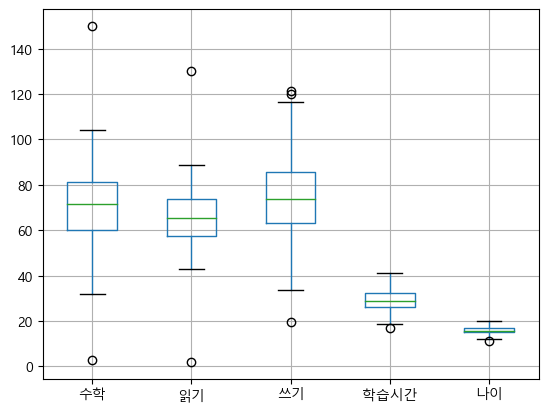

In [68]:
# boxplot으로 확인하기
df.boxplot()
plt.show()

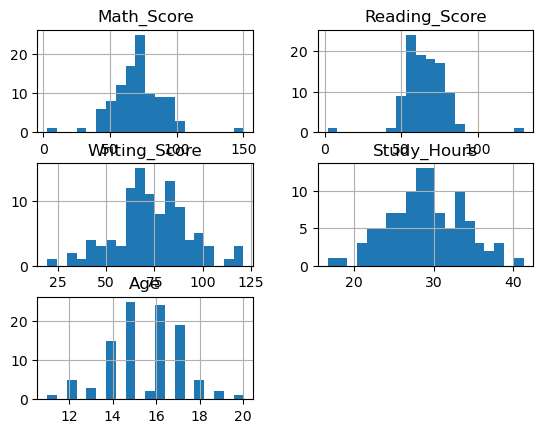

In [55]:
# histplot 으로 확인하기
차트 = df.hist(bins=20, )
plt.show()

#### **2. IQR로 이상치 탐지하기**

In [77]:
# 데이터 구조 파악하기
df.shape

(102, 5)

In [78]:
# 컬럼 확인하기
df.columns

Index(['Math_Score', 'Reading_Score', 'Writing_Score', 'Study_Hours', 'Age'], dtype='object')

In [79]:
# 컬럼 이름 변경
df.columns = ['수학', '읽기', '쓰기', '학습시간', '나이']

In [80]:
df.columns

Index(['수학', '읽기', '쓰기', '학습시간', '나이'], dtype='object')

In [81]:
# 데이터 구조 확인하기
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102 entries, 0 to 101
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   수학      102 non-null    float64
 1   읽기      102 non-null    float64
 2   쓰기      102 non-null    float64
 3   학습시간    102 non-null    float64
 4   나이      102 non-null    float64
dtypes: float64(5)
memory usage: 4.8 KB


In [69]:
# 데이터 통계량 확인하기
df.describe()

,수학,읽기,쓰기,학습시간,나이
count,102.000000,102.000000,102.000000,102.000000,102.000000
mean,71.006981,65.823657,73.815355,29.016016,15.500000
std,18.272457,13.678567,18.945560,4.623715,1.619803
min,3.000000,2.000000,19.548145,16.704139,11.000000
25%,60.056112,57.532202,63.176350,26.231057,15.000000
50%,71.411442,65.246549,73.815355,28.926053,15.750000
75%,81.295764,73.537137,85.463690,32.415556,17.000000
max,150.000000,130.000000,121.078334,41.283617,20.000000


#### **quantile() :** 
- 0.25 - 1사분위, 0.5 - 2사분위, 0.75 - 3사분위**
- IQR(Interquartile Range) : 3사분위 - 1사분위 (전체 데이터의 50%)
- 이상치 : 1사분위 아래로 1.5xIQR 범위를 벗어난 데이터, 3사분위 위로 1.5xIQR 범위 벗어난 데이터

In [71]:
# IQR(Interquartile Range)**을 사용하여 이상치를 탐지
Q1 = df['수학'].quantile(0.25) # 1사분위
Q3 = df['수학'].quantile(0.75) # 3사분위
IQR = Q3 - Q1
IQR

21.2396519048525

In [72]:
# 하한선 확인
하한선 = Q1 - 1.5 * IQR

# 상한선 확인
상한선 = Q3 + 1.5 * IQR

print(하한선, 상한선)

28.19663425393819 113.15524187334819


In [73]:
# 거래량 이상치 확인
하한조건 = (df['수학'] < 하한선)
상한조건 = (df['수학'] > 상한선)

이상치 = df.loc[하한조건 | 상한조건, '수학']
이상치

100    150.0
101      3.0
Name: 수학, dtype: float64

In [82]:
# 이상치 제거한 데이터
df_cleaned = df.loc[(df['수학'] >= 하한선) & (df['수학'] <= 상한선)]
df_cleaned

,수학,읽기,쓰기,학습시간,나이
0,96.460785,83.831507,67.616363,23.467366,15.0
1,76.002358,51.522409,70.212416,38.290653,14.0
2,84.681070,52.295150,96.993192,29.409180,17.0
3,103.613398,74.693967,88.105275,26.599109,16.0
4,98.013370,53.268766,87.802631,33.331915,13.0
...,...,...,...,...,...
93,84.649586,53.319065,53.799684,21.917629,17.0
94,75.345496,70.232767,72.281006,28.540813,20.0
95,80.598598,63.284537,97.737827,26.192539,15.0
96,70.157500,72.717906,76.954499,34.289620,15.0


In [83]:
df_cleaned.shape

(98, 5)

In [84]:
# 통계량 확인
df_cleaned.describe()

,수학,읽기,쓰기,학습시간,나이
count,98.000000,98.000000,98.000000,98.000000,98.000000
mean,70.834475,65.479748,73.797177,28.877612,15.520408
std,15.340922,10.205857,19.300209,4.609131,1.644921
min,31.705153,42.765968,19.548145,16.704139,11.000000
25%,60.056112,57.532202,63.058689,26.182595,15.000000
50%,70.920119,64.890982,73.492823,28.707020,16.000000
75%,81.295764,73.182422,86.363760,32.175105,17.000000
max,104.046319,88.831448,121.078334,41.283617,20.000000


#### **표준 편차로 구하기**
- 평균 + 3 X 표준편차 이상
- 평균 - 3 X 표준편차 이하

In [91]:
# 표준편차를 사용한 Reading_Score 이상치 제거
평균 = df['읽기'].mean()
표준편차 = df['읽기'].std()

print(평균, 표준편차)

65.82365657568626 13.678566522430037


In [92]:
하한선 = 평균 - (3 * 표준편차)
상한선 = 평균 + (3 * 표준편차)

print(하한선, 상한선)

24.78795700839615 106.85935614297637


In [94]:
# 이상치 제거 (범위 밖의 값 제거)
df_reading = df[(df['읽기'] >= 하한선) & (df['읽기'] <= 상한선)]

print("\n표준편차를 활용해 수학점수 이상치 제거 후 데이터프레임:")
print(df_reading['읽기'])


표준편차를 활용해 수학점수 이상치 제거 후 데이터프레임:
0     83.831507
1     51.522409
2     52.295150
3     74.693967
4     53.268766
        ...    
95    63.284537
96    72.717906
97    73.235042
98    86.632359
99    78.365279
Name: 읽기, Length: 100, dtype: float64
